### Backorder Prediction - 종합 데이터 분석

| | Dataset 1 | 
|---|---|
| 출처 | [Kaggle](https://www.kaggle.com/datasets/ztrimus/backorder-dataset) |
| Train | `Kaggle_Training_Dataset_v2.csv` |
| Test | `Kaggle_Test_Dataset_v2.csv` |

---


| 데이터 타입 | 컬럼 이름 | 개수 |
|---|---|---|
| 수치형 컬럼 | national_inv, lead_time, in_transit_qty, forecast_3_month, forecast_6_month, forecast_9_month, sales_1_month, sales_3_month, sales_6_month, sales_9_month, min_bank, pieces_past_due, perf_6_month_avg, perf_12_month_avg, local_bo_qty | 15개 |
| 범주형 컬럼 | sku, potential_issue, deck_risk, oe_constraint, ppap_risk, stop_auto_buy, rev_stop, went_on_backorder | 8개 |

---
---
---

| 컬럼명 | 데이터 타입 | 단위/형태 | 의미 |
|---|---|---|---|
| `sku` | `object` | ID / string | 제품 식별자 |
| `national_inv` | `float64` | count | 현재 재고량 |
| `lead_time` | `float64` | days | 조달/운송 리드타임 |
| `in_transit_qty` | `float64` | count | 운송 중 수량 |
| `forecast_3_month` | `float64` | count | 향후 3개월 판매 예측 |
| `forecast_6_month` | `float64` | count | 향후 6개월 판매 예측 |
| `forecast_9_month` | `float64` | count | 향후 9개월 판매 예측 |
| `sales_1_month` | `float64` | count | 과거 1개월 판매량 |
| `sales_3_month` | `float64` | count | 과거 3개월 판매량 |
| `sales_6_month` | `float64` | count | 과거 6개월 판매량 |
| `sales_9_month` | `float64` | count | 과거 9개월 판매량 |
| `min_bank` | `float64` | count | 최소 권장 재고량 |
| `potential_issue` | `object` | binary flag | 공급 이슈 여부 |
| `pieces_past_due` | `float64` | count | 지연/미입고 수량 |
| `perf_6_month_avg` | `float64` | ratio | 공급원 6개월 성과 평균 |
| `perf_12_month_avg` | `float64` | ratio | 공급원 12개월 성과 평균 |
| `local_bo_qty` | `float64` | count | 로컬 overdue/backorder 수량 |
| `deck_risk` | `object` | binary flag | 리스크 플래그 |
| `oe_constraint` | `object` | binary flag | 제약 플래그 |
| `ppap_risk` | `object` | binary flag | 리스크 플래그 |
| `stop_auto_buy` | `object` | binary flag | 자동구매 중단 플래그 |
| `rev_stop` | `object` | binary flag | 중지 관련 플래그 |
| `went_on_backorder` | `object` | binary target | 백오더 발생 여부 |
|


In [53]:
import hashlib
from itertools import combinations
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_style('whitegrid')
sns.set_palette('Set2')

print("Libraries loaded")


Libraries loaded


In [54]:
Train = Path('dataset_2/Back_order_train.csv')
Test = Path('dataset_2/Back_order_test.csv')
DATASET_FILES = {'Train': Train, 'Test': Test}

# SHA-256 해시 함수 정의
def file_hash(path):
    sha256 = hashlib.sha256()
    with open(path, 'rb') as f:
        for byte_block in iter(lambda: f.read(4096), b""):
            sha256.update(byte_block)
    return sha256.hexdigest()

# 모든 파일의 해시값 미리 계산
file_hashes = {name : file_hash(path) for name, path in DATASET_FILES.items()}

# 중복 방지하며 데이터 로드
loaded_by_hash = {}
datasets = {}

for name, path in DATASET_FILES.items():
    digest = file_hashes[name]
    
    if digest not in loaded_by_hash:
        # 처음 보는 해시값이면 실제로 로드
        loaded_by_hash[digest] = pd.read_csv(path)
    else:
        # 같은 해시값이 존재하면 기존 데이터 재사용
        print(f"⚠️ Reused {path}: 동일한 내용의 파일이 이미 로드되었습니다.")
    datasets[name] = loaded_by_hash[digest]

# 데이터 지정
df_train = datasets['Train']
df_test = datasets['Test']

# 5. EDA를 위한 복사 (메모리 절약을 위해 deep=False)
df_train_eda = df_train.copy(deep=False)
df_test_eda = df_test.copy(deep=False)

print("\n[성공] 데이터셋 로드 및 EDA 준비 완료")
print(f"메모리 사용량: {df_train_eda.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"메모리 사용량: {df_test_eda.memory_usage(deep=True).sum() / 1024**2:.1f} MB")


[성공] 데이터셋 로드 및 EDA 준비 완료
메모리 사용량: 828.2 MB
메모리 사용량: 119.0 MB


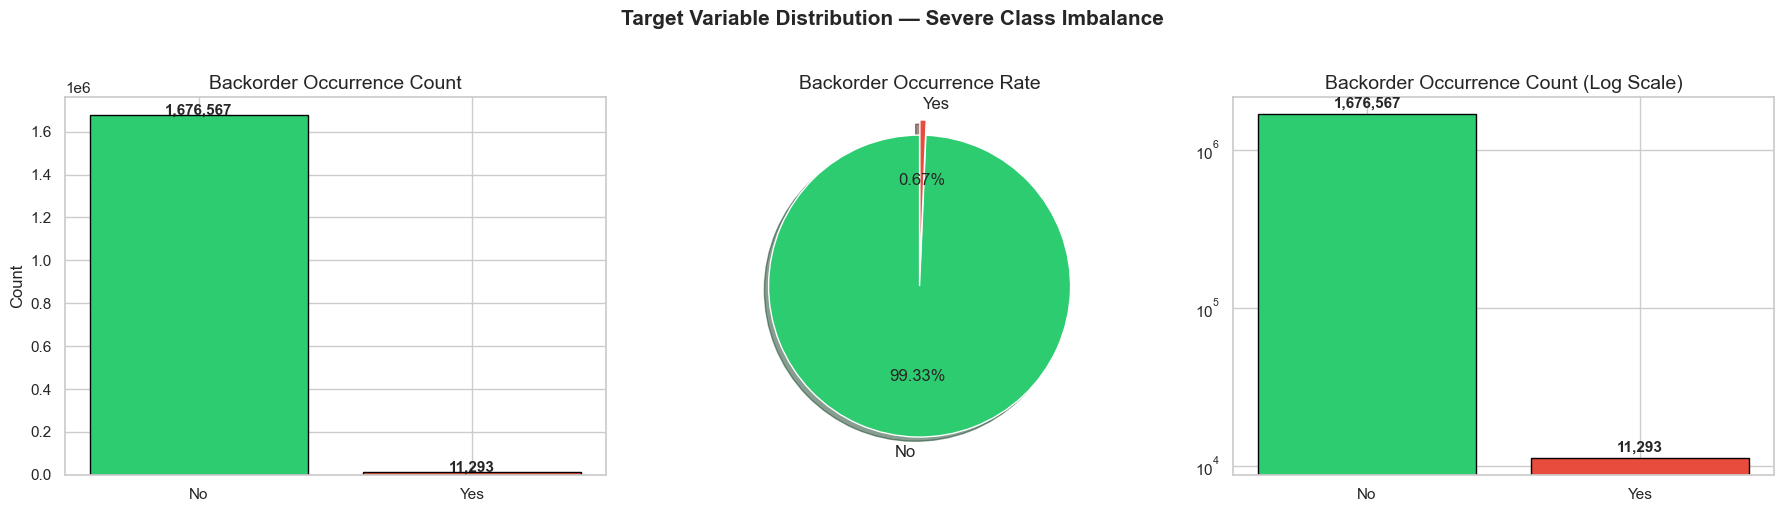


class imbalance ratio : No:Yes = 148:1


In [55]:
target_counts = df_train_eda['went_on_backorder'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax1 = axes[0]
bars = ax1.bar(target_counts.index, target_counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
ax1.set_title('Backorder Occurrence Count')
ax1.set_ylabel('Count')
for bar, val in zip(bars, target_counts.values):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5000, f'{val:,}', ha='center', fontsize=11, fontweight='bold')

ax2 = axes[1]
ax2.pie(target_counts.values, labels=target_counts.index, autopct='%1.2f%%',
        colors=['#2ecc71','#e74c3c'], startangle=90, explode=[0,0.1], shadow=True, textprops={'fontsize':12})
ax2.set_title('Backorder Occurrence Rate')

ax3 = axes[2]
ax3.bar(target_counts.index, target_counts.values, color=['#2ecc71','#e74c3c'], edgecolor='black')
ax3.set_yscale('log')
ax3.set_title('Backorder Occurrence Count (Log Scale)')
for bar, val in zip(ax3.patches, target_counts.values):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.1, f'{val:,}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Target Variable Distribution — Severe Class Imbalance', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f"\nclass imbalance ratio : No:Yes = {target_counts['No']/target_counts['Yes']:.0f}:1")


In [56]:
df_train_eda.head()

,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,...,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
0,1026827,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,No,No,No,Yes,No,No
1,1043384,2.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.99,0.99,0.0,No,No,No,Yes,No,No
2,1043696,2.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,Yes,No,No,Yes,No,No
3,1043852,7.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.10,0.13,0.0,No,No,No,Yes,No,No
4,1044048,8.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,Yes,No,No,Yes,No,No


In [57]:
df_train_eda.tail()

,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,...,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
1687856,1373987,-1.0,NaN,0.0,5.0,7.0,9.0,1.0,3.0,3.0,...,0.0,-99.00,-99.00,1.0,No,No,No,Yes,No,No
1687857,1524346,-1.0,9.0,0.0,7.0,9.0,11.0,0.0,8.0,11.0,...,0.0,0.86,0.84,1.0,Yes,No,No,No,No,Yes
1687858,1439563,62.0,9.0,16.0,39.0,87.0,126.0,35.0,63.0,153.0,...,0.0,0.86,0.84,6.0,No,No,No,Yes,No,No
1687859,1502009,19.0,4.0,0.0,0.0,0.0,0.0,2.0,7.0,12.0,...,0.0,0.73,0.78,1.0,No,No,No,Yes,No,No
1687860,(1687860 rows),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [58]:
# 데이터 타입 및 결측치 요약
info_df = pd.DataFrame({
    'dtype': df_train_eda.dtypes, # 데이터 타입
    'non_null': df_train_eda.notnull().sum(), # 정상 데이터 개수
    'null_count': df_train_eda.isnull().sum(), # 결측치 개수
    'null_pct': (df_train_eda.isnull().sum() / len(df_train_eda) * 100).round(2), # 결측치 비율(null percentage)
    'nunique': df_train_eda.nunique() # 고유값 개수
})
info_df

,dtype,non_null,null_count,null_pct,nunique
sku,object,1687861,0,0.00,1687861
national_inv,float64,1687860,1,0.00,14969
lead_time,float64,1586967,100894,5.98,32
in_transit_qty,float64,1687860,1,0.00,5230
forecast_3_month,float64,1687860,1,0.00,7825
forecast_6_month,float64,1687860,1,0.00,11114
forecast_9_month,float64,1687860,1,0.00,13662
sales_1_month,float64,1687860,1,0.00,5764
sales_3_month,float64,1687860,1,0.00,10495
sales_6_month,float64,1687860,1,0.00,14818


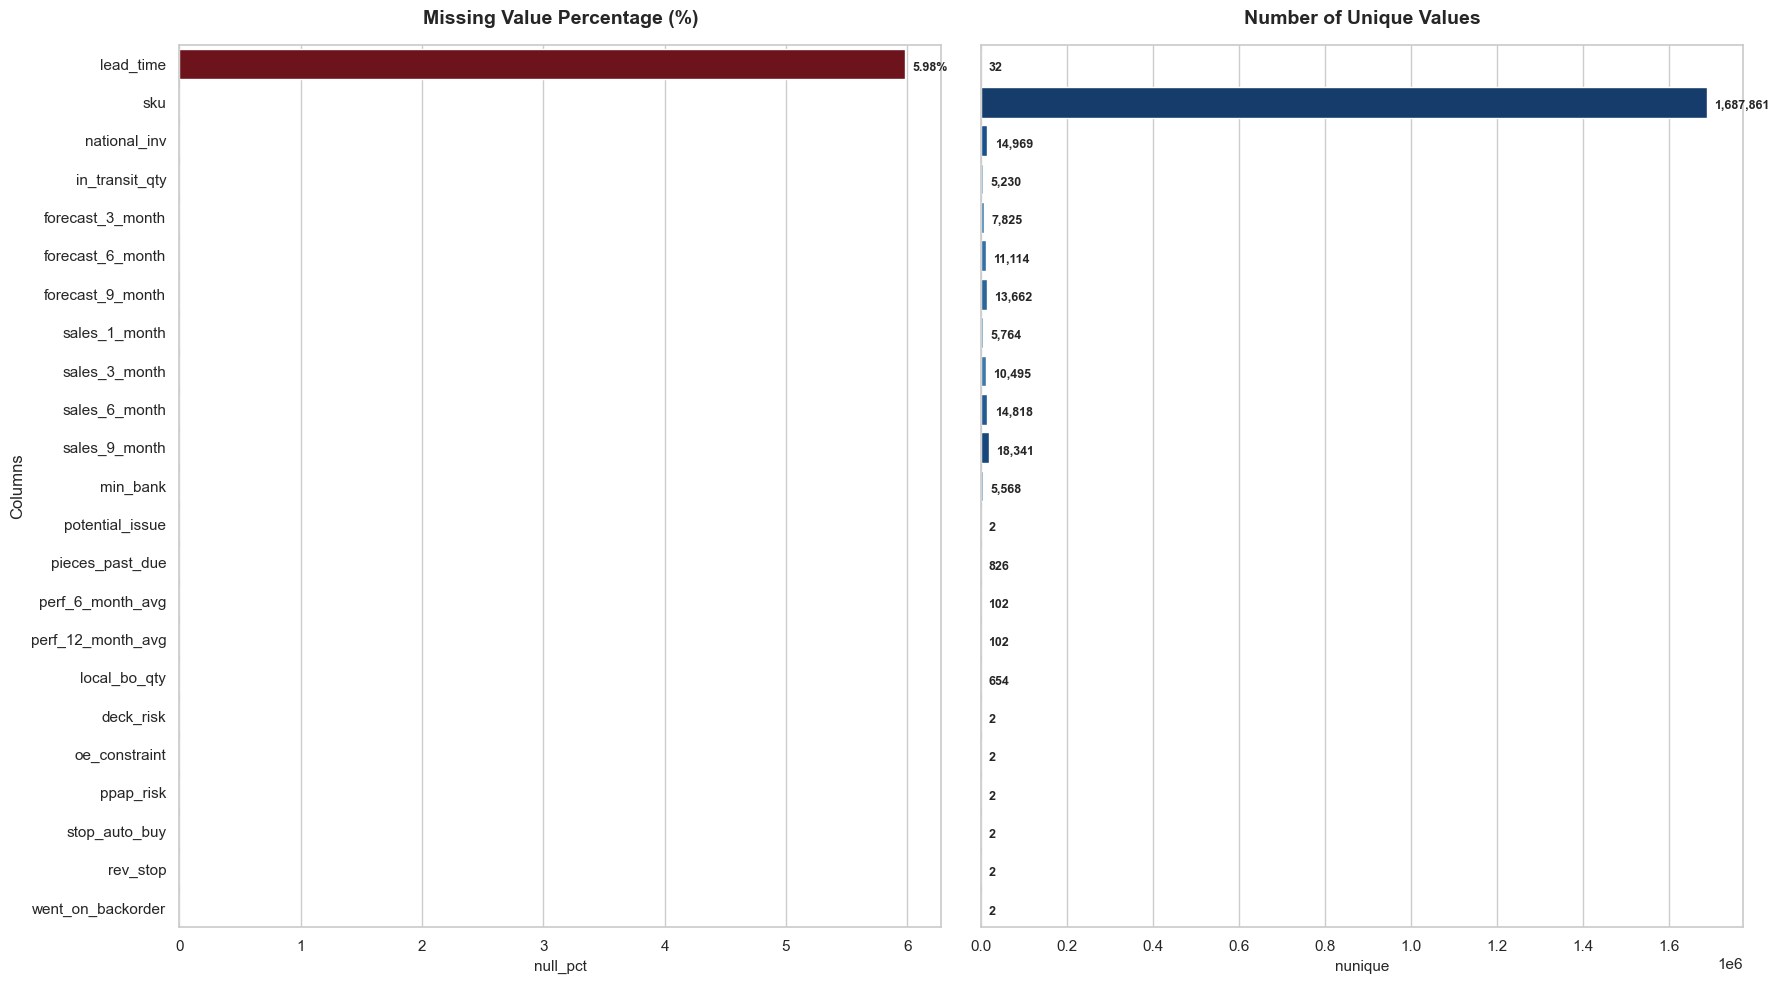

In [59]:
# 시각화할 지표
metrics = ['null_pct', 'nunique']
titles = ['Missing Value Percentage (%)', 'Number of Unique Values']
palettes = ['Reds_r', 'Blues_r']

# 1행 2열 그래프
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 10), sharey=True)
sns.set_theme(style="whitegrid")

# 그리기
for i, metric in enumerate(metrics):
    # 각 지표 기준으로 내림차순 정렬
    plot_df = info_df.sort_values(by=metric, ascending=False)
    
    # 가로 막대 그래프 그리기
    ax = sns.barplot(
        x=metric, 
        y=plot_df.index, 
        data=plot_df, 
        palette=palettes[i], 
        ax=axes[i]
    )
    
    # 막대 끝에 실제 수치 텍스트 표시
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            # 정수형태(nunique)와 실수형태(null_pct) 표현 분기
            text_format = f'{width:,.0f}' if metric == 'nunique' else f'{width:.2f}%'
            ax.text(
                width + (plot_df[metric].max() * 0.01),  # 막대 끝에서 살짝 띄우기
                p.get_y() + p.get_height()/2 + 0.1, 
                text_format, 
                ha='left', va='center', fontsize=9, fontweight='bold'
            )
            
    # 제목 및 레이블 설정
    ax.set_title(titles[i], fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel(metric, fontsize=11)
    if i == 0:
        ax.set_ylabel('Columns', fontsize=12)
    else:
        ax.set_ylabel('') # 오른쪽 그래프의 y축 레이블은 숨김 (중복 방지)

plt.tight_layout()
plt.show()

In [60]:
# Train Test 중복 검사
sku_col = 'sku' if 'sku' in df_train_eda.columns else None
train_skus = set(df_train_eda[sku_col]) if sku_col else set()
test_skus = set(df_test_eda[sku_col]) if sku_col else set()
duplicate_skus = train_skus.intersection(test_skus)
if duplicate_skus:
    print(f"⚠️ 중복된 SKU 발견: {len(duplicate_skus)}개")
    print(f"중복된 SKU 예시: {list(duplicate_skus)[:10]}")

print(f"  Train SKU: {len(train_skus):,}")
print(f"  Test SKU:  {len(test_skus):,}")
print(f"  겹치는 SKU: {len(duplicate_skus):,} ({len(duplicate_skus)/max(len(test_skus),1)*100:.1f}% of test)")

  Train SKU: 1,687,861
  Test SKU:  242,076
  겹치는 SKU: 0 (0.0% of test)


### 수치형 범주형 분리

In [61]:
numeric_columns = df_train_eda.select_dtypes(include=[np.number]).columns.tolist()
print(f"수치형 컬럼: {numeric_columns}")

categorical_columns = df_train_eda.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"범주형 컬럼: {categorical_columns}")

수치형 컬럼: ['national_inv', 'lead_time', 'in_transit_qty', 'forecast_3_month', 'forecast_6_month', 'forecast_9_month', 'sales_1_month', 'sales_3_month', 'sales_6_month', 'sales_9_month', 'min_bank', 'pieces_past_due', 'perf_6_month_avg', 'perf_12_month_avg', 'local_bo_qty']
범주형 컬럼: ['sku', 'potential_issue', 'deck_risk', 'oe_constraint', 'ppap_risk', 'stop_auto_buy', 'rev_stop', 'went_on_backorder']


### **결측치 분석**

컬럼별 결측치 개수:
national_inv              1
lead_time            100894
in_transit_qty            1
forecast_3_month          1
forecast_6_month          1
forecast_9_month          1
sales_1_month             1
sales_3_month             1
sales_6_month             1
sales_9_month             1
min_bank                  1
potential_issue           1
pieces_past_due           1
perf_6_month_avg          1
perf_12_month_avg         1
local_bo_qty              1
deck_risk                 1
oe_constraint             1
ppap_risk                 1
stop_auto_buy             1
rev_stop                  1
went_on_backorder         1
dtype: int64

컬럼별 결측치 비율:
lead_time    5.98
dtype: float64


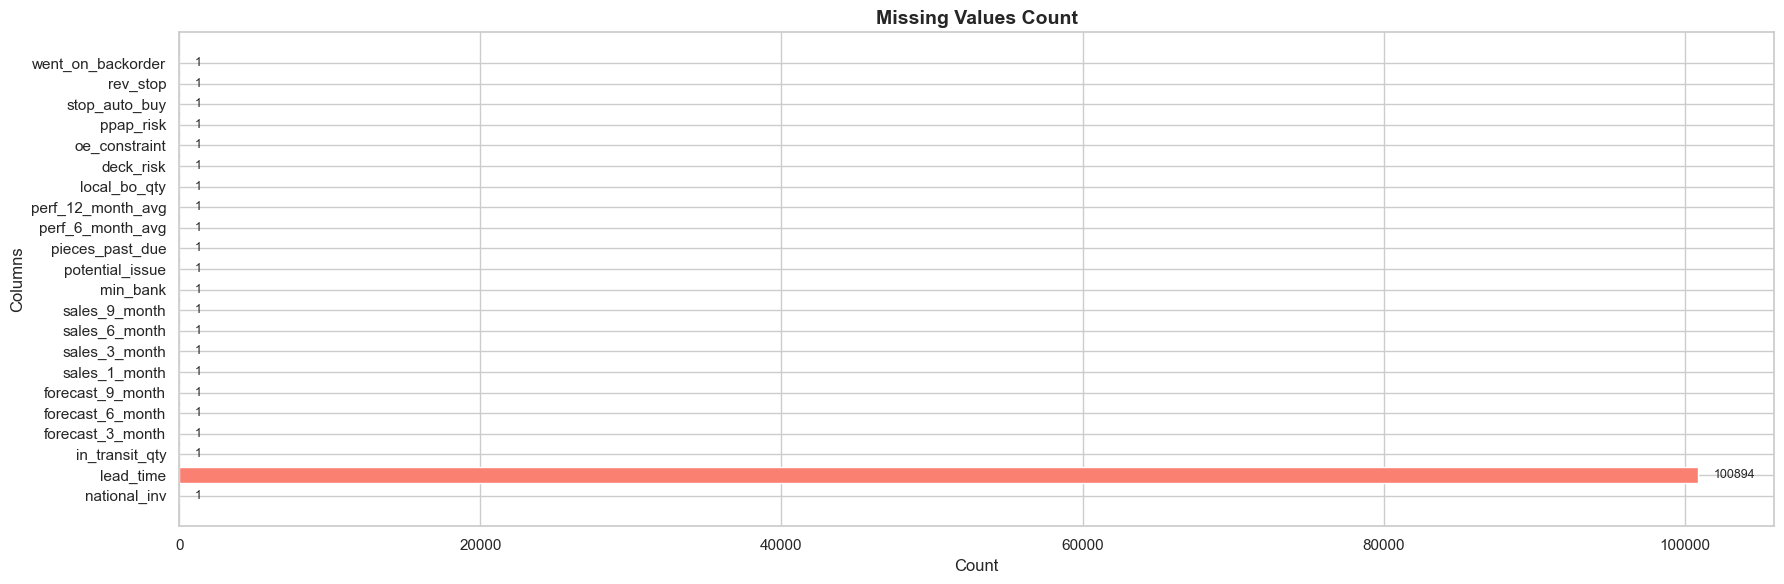

In [62]:
missing = df_train_eda.isnull().sum()
print("컬럼별 결측치 개수:")
print(missing[missing > 0])

fig, axes = plt.subplots(1, 1, figsize=(18, 6))

bars = axes.barh(missing[missing > 0].index, missing[missing > 0].values, color='salmon')
axes.set_title('Missing Values Count', fontsize=14, fontweight='bold')
axes.set_xlabel('Count', fontsize=12)
axes.set_ylabel('Columns', fontsize=12)
for bar, value in zip(bars, missing[missing > 0].values):
    axes.text(value + (missing.max() * 0.01), bar.get_y() + bar.get_height()/2, f'{value}', va='center', fontsize=9) 

missing_pct = (missing / len(df_train_eda) * 100).round(2)
print("\n컬럼별 결측치 비율:")
print(missing_pct[missing_pct > 0])

plt.tight_layout()
plt.show()

In [63]:
print(f"\nlead_time 결측률: {missing_pct.get('lead_time', 0):.2f}% ({missing.get('lead_time', 0):,}건)")


lead_time 결측률: 5.98% (100,894건)


### **`lead_time`이 비어있는 100,894개 행 분석**

In [64]:
# lead_time이 결측치인 행의 sku 출력
lead_time_null_rows = df_train_eda[df_train_eda['lead_time'].isnull()]

# lead_time이 결측된 데이터 프레임 정의
lead_time_null_df = lead_time_null_rows.copy()

target_col = 'went_on_backorder'

# 타겟 변수 분포 확인
target_dist = lead_time_null_df[target_col].value_counts(normalize=True) * 100
print(f"\nlead_time 결측치 행의 '{target_col}' 분포:")
print(target_dist.round(2))

# local_bo_qty 분포 확인
local_bo_qty_dist = lead_time_null_df['local_bo_qty'].value_counts(normalize=True) * 100
print(f"\nlead_time 결측치 행의 'local_bo_qty' 분포:")
print(local_bo_qty_dist.round(2))


lead_time 결측치 행의 'went_on_backorder' 분포:
went_on_backorder
No     99.68
Yes     0.32
Name: proportion, dtype: float64

lead_time 결측치 행의 'local_bo_qty' 분포:
local_bo_qty
0.0      99.35
1.0       0.15
2.0       0.09
4.0       0.04
5.0       0.03
         ...  
939.0     0.00
85.0      0.00
48.0      0.00
132.0     0.00
37.0      0.00
Name: proportion, Length: 112, dtype: float64


### **22개의 컬럼에서 단 1개만 Missing Value가 나타난다. 확인해보자**

In [65]:
# 결측치가 있는 행 인덱스 확인
null_rows = df_train_eda[df_train_eda.isnull().any(axis=1)]
print(f"결측치가 1개라도 있는 행 수: {len(null_rows)}")
print(f"해당 행 인덱스: {null_rows.index.tolist()[:10]}")

# 마지막 행 확인
print(df_train_eda.iloc[-1])
print(f"\n결측치 수: {df_train_eda.iloc[-1].isnull().sum()} / {len(df_train_eda.columns)}")

결측치가 1개라도 있는 행 수: 100894
해당 행 인덱스: [0, 2, 4, 6, 8, 11, 12, 13, 14, 18]
sku                  (1687860 rows)
national_inv                    NaN
lead_time                       NaN
in_transit_qty                  NaN
forecast_3_month                NaN
forecast_6_month                NaN
forecast_9_month                NaN
sales_1_month                   NaN
sales_3_month                   NaN
sales_6_month                   NaN
sales_9_month                   NaN
min_bank                        NaN
potential_issue                 NaN
pieces_past_due                 NaN
perf_6_month_avg                NaN
perf_12_month_avg               NaN
local_bo_qty                    NaN
deck_risk                       NaN
oe_constraint                   NaN
ppap_risk                       NaN
stop_auto_buy                   NaN
rev_stop                        NaN
went_on_backorder               NaN
Name: 1687860, dtype: object

결측치 수: 22 / 23


**그냥 파싱 잔여물임**
- df_train_eda에서 제거

In [66]:
# 전체 컬럼의 절반 이상이 NaN인 행만 제거
df_train_eda = df_train_eda.dropna(thresh=len(df_train_eda.columns) // 2)

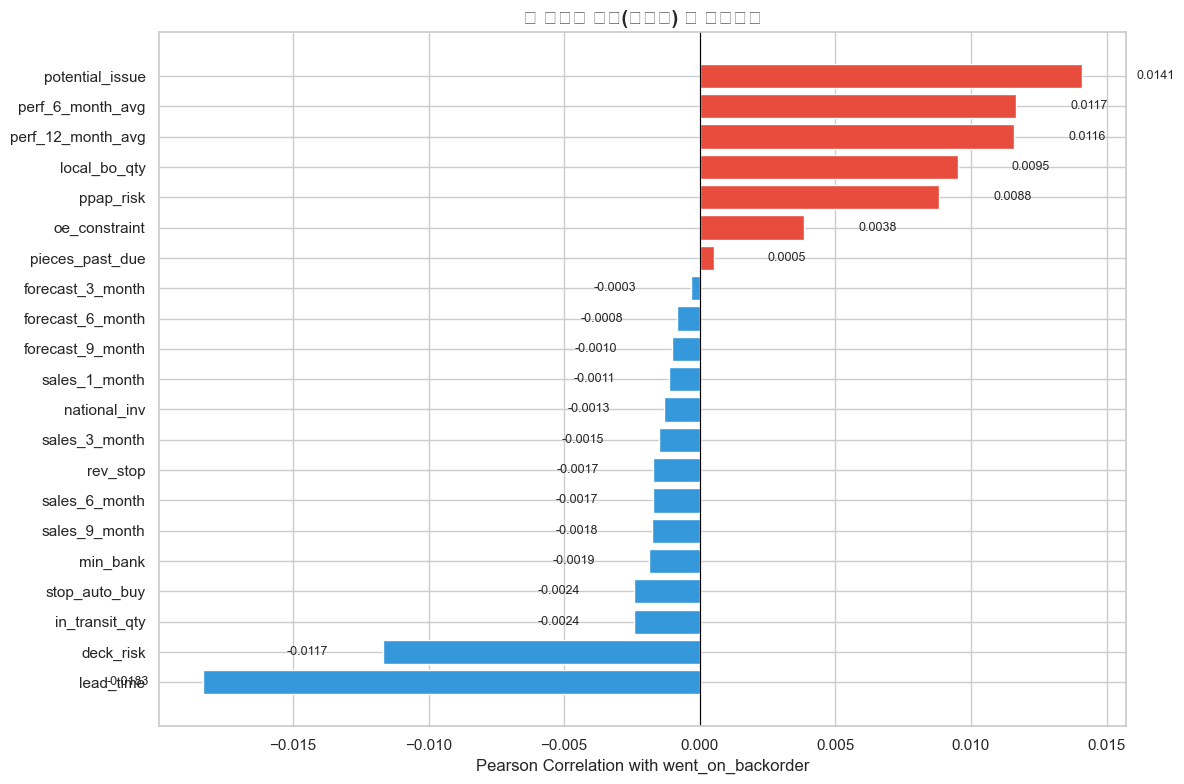

In [67]:
# 1) 바이너리 플래그를 숫자로 변환
df_corr = df_train_eda.copy()
binary_flags = ['potential_issue', 'deck_risk', 'oe_constraint', 
                'ppap_risk', 'stop_auto_buy', 'rev_stop', 'went_on_backorder']
for col in binary_flags:
    if col in df_corr.columns:
        df_corr[col] = (df_corr[col] == 'Yes').astype(int)

# 2) sku 제거, 수치형만
df_corr = df_corr.drop(columns=['sku'], errors='ignore')

# 3) 타겟과의 상관계수 계산 + 시각화
target_corr = df_corr.corr()['went_on_backorder'].drop('went_on_backorder').sort_values()

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with went_on_backorder')
ax.set_title('각 피처와 타겟(백오더) 간 상관계수', fontsize=14, fontweight='bold')

for i, (idx, val) in enumerate(target_corr.items()):
    ax.text(val + 0.002 if val >= 0 else val - 0.002, i,
            f'{val:.4f}', va='center', fontsize=9,
            ha='left' if val >= 0 else 'right')

plt.tight_layout()
plt.show()

- 상관 계수가 극도로 낮다 -> 타겟 변수가 0.67%이기 때문
- perf_6 & 12_month_avg -> 공급 업체 성과가 높을수록 백오더가 많다고? 확인 필요
- lead_time이 가장 강한 음의 상관관계-> 걸리는 시간이 큰수록 백오더가 없다고? 확인 필요

**데이터 분포 확인**

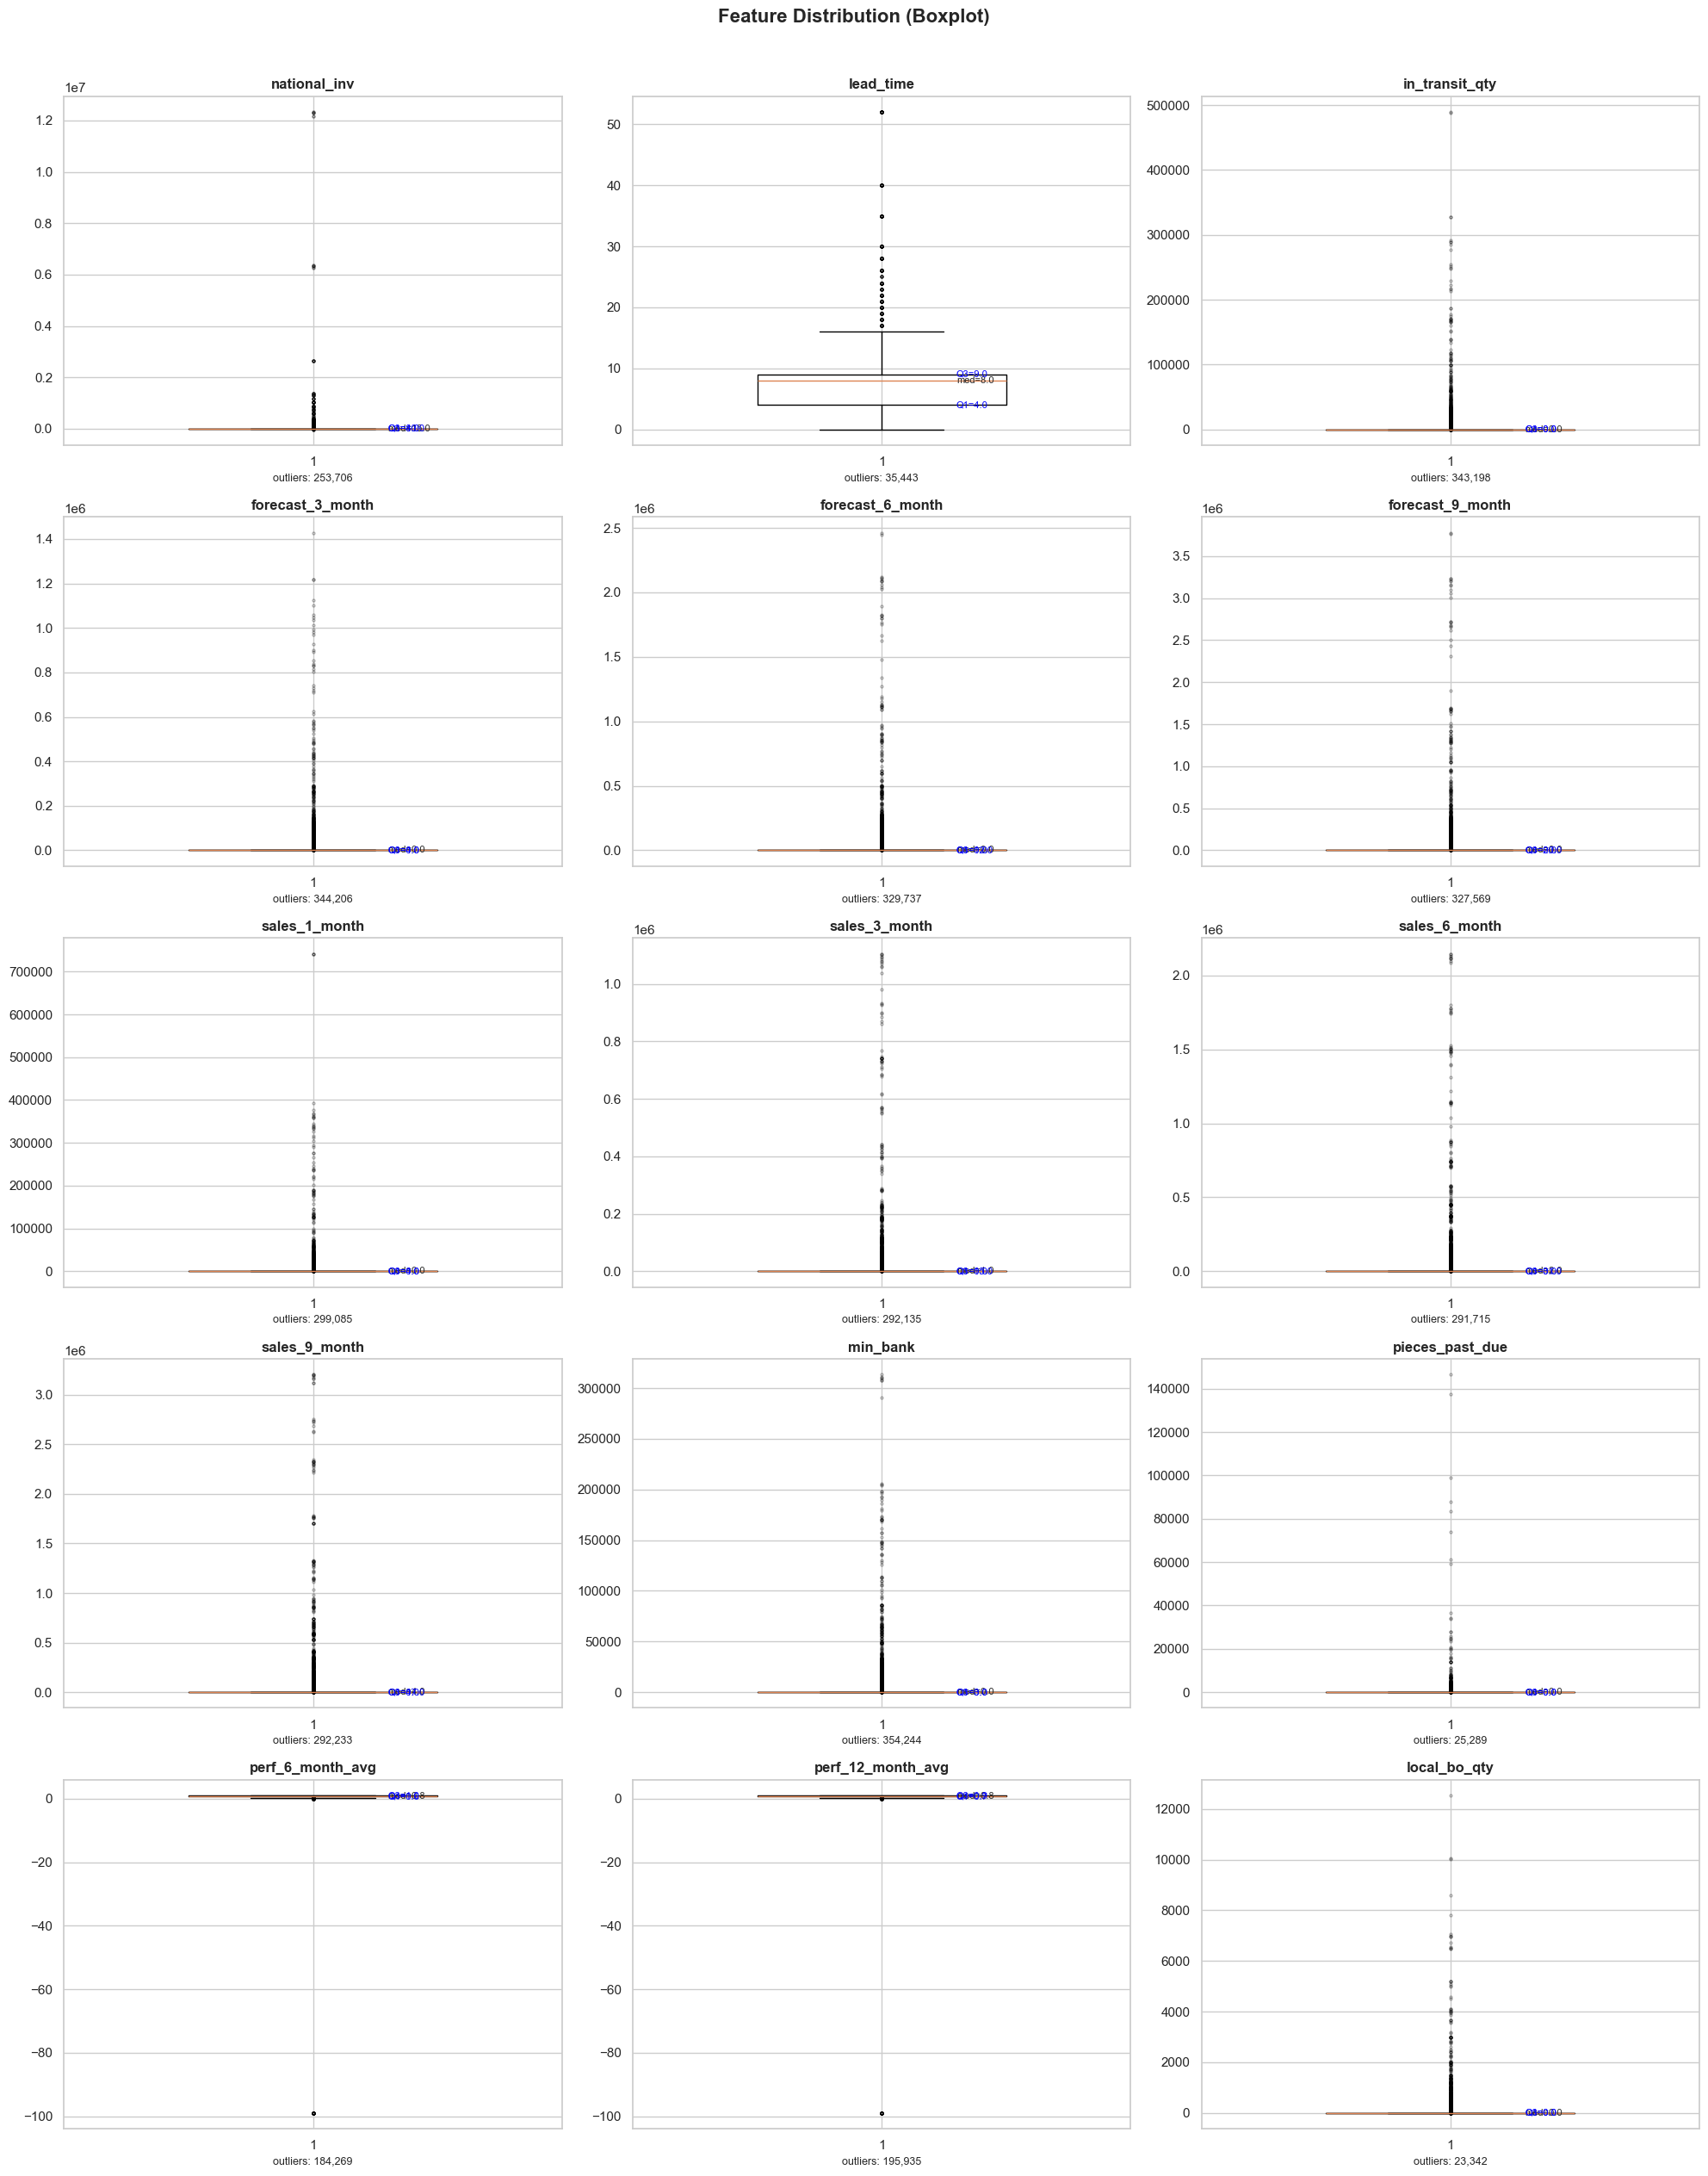

In [68]:
numeric_cols = df_train_eda.select_dtypes(include=[np.number]).columns.tolist()

fig, axes = plt.subplots(5, 3, figsize=(20, 25))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if i >= len(axes):
        break
    data = df_train_eda[col].dropna()
    axes[i].boxplot(data, vert=True, widths=0.5,
                    flierprops=dict(marker='o', markersize=2, alpha=0.3))
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    
    q1, med, q3 = data.quantile([0.25, 0.5, 0.75])
    iqr = q3 - q1
    axes[i].text(1.15, med, f'med={med:.1f}', fontsize=8, va='center')
    axes[i].text(1.15, q1, f'Q1={q1:.1f}', fontsize=8, va='center', color='blue')
    axes[i].text(1.15, q3, f'Q3={q3:.1f}', fontsize=8, va='center', color='blue')
    
    outlier_low = data[data < q1 - 1.5 * iqr].count()
    outlier_high = data[data > q3 + 1.5 * iqr].count()
    axes[i].set_xlabel(f'outliers: {outlier_low + outlier_high:,}', fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distribution (Boxplot)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

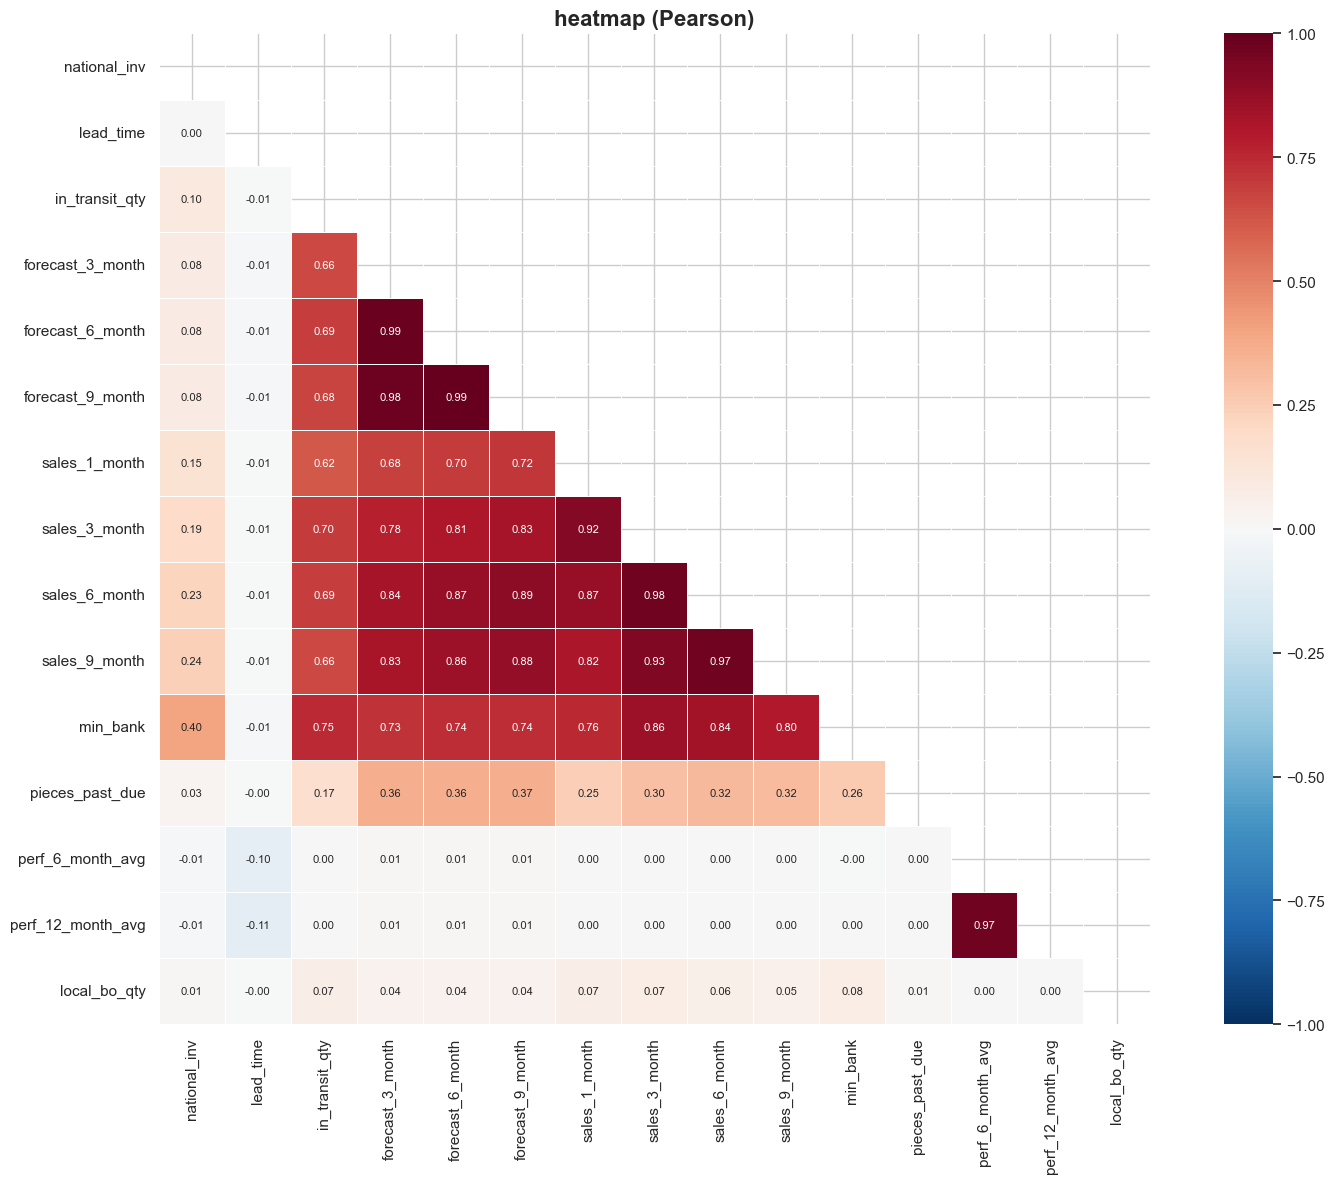

In [69]:
corr_matrix = df_train_eda[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, square=True, ax=ax, annot_kws={'size':8}, vmin=-1, vmax=1)
ax.set_title('heatmap (Pearson)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


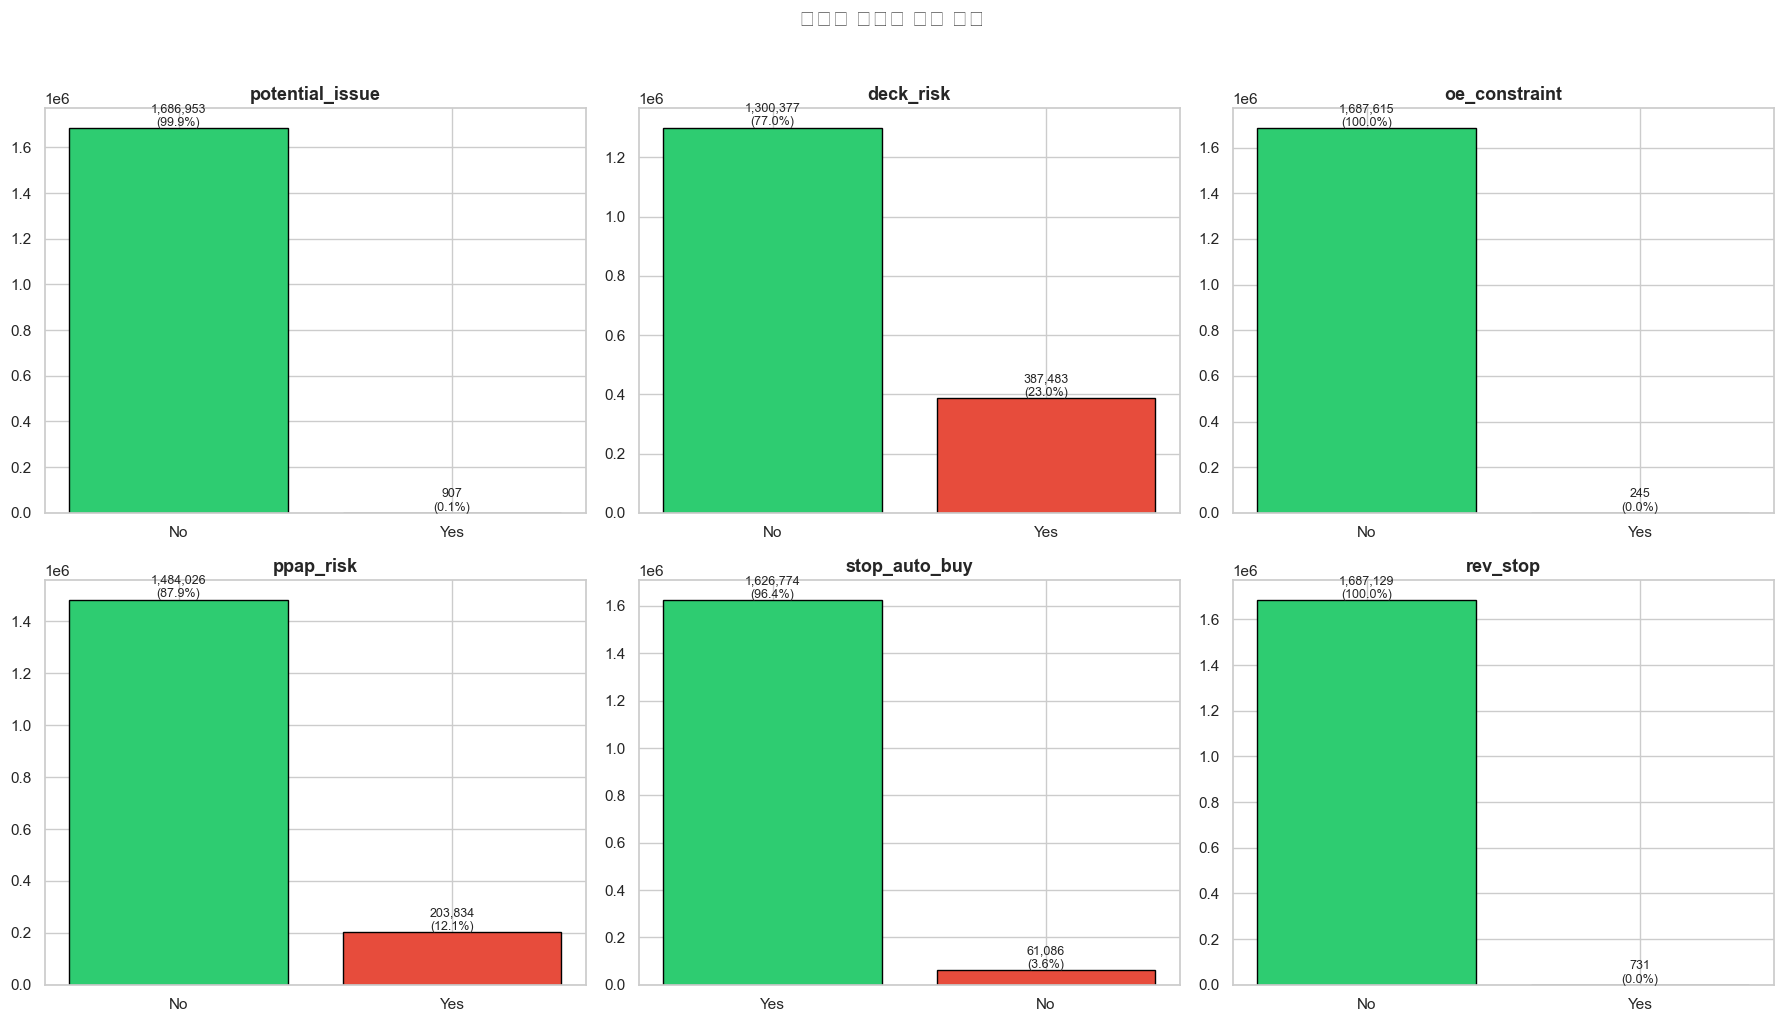

In [70]:
binary_flags = ['potential_issue', 'deck_risk', 'oe_constraint', 'ppap_risk', 'stop_auto_buy', 'rev_stop']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(binary_flags):
    ax = axes[i]
    counts = df[col].value_counts()
    bars = ax.bar(counts.index.astype(str), counts.values, color=['#2ecc71','#e74c3c'], edgecolor='black')
    ax.set_title(col, fontweight='bold', fontsize=13)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+len(df)*0.005,
                f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=9)
plt.suptitle('범주형 플래그 변수 분포', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


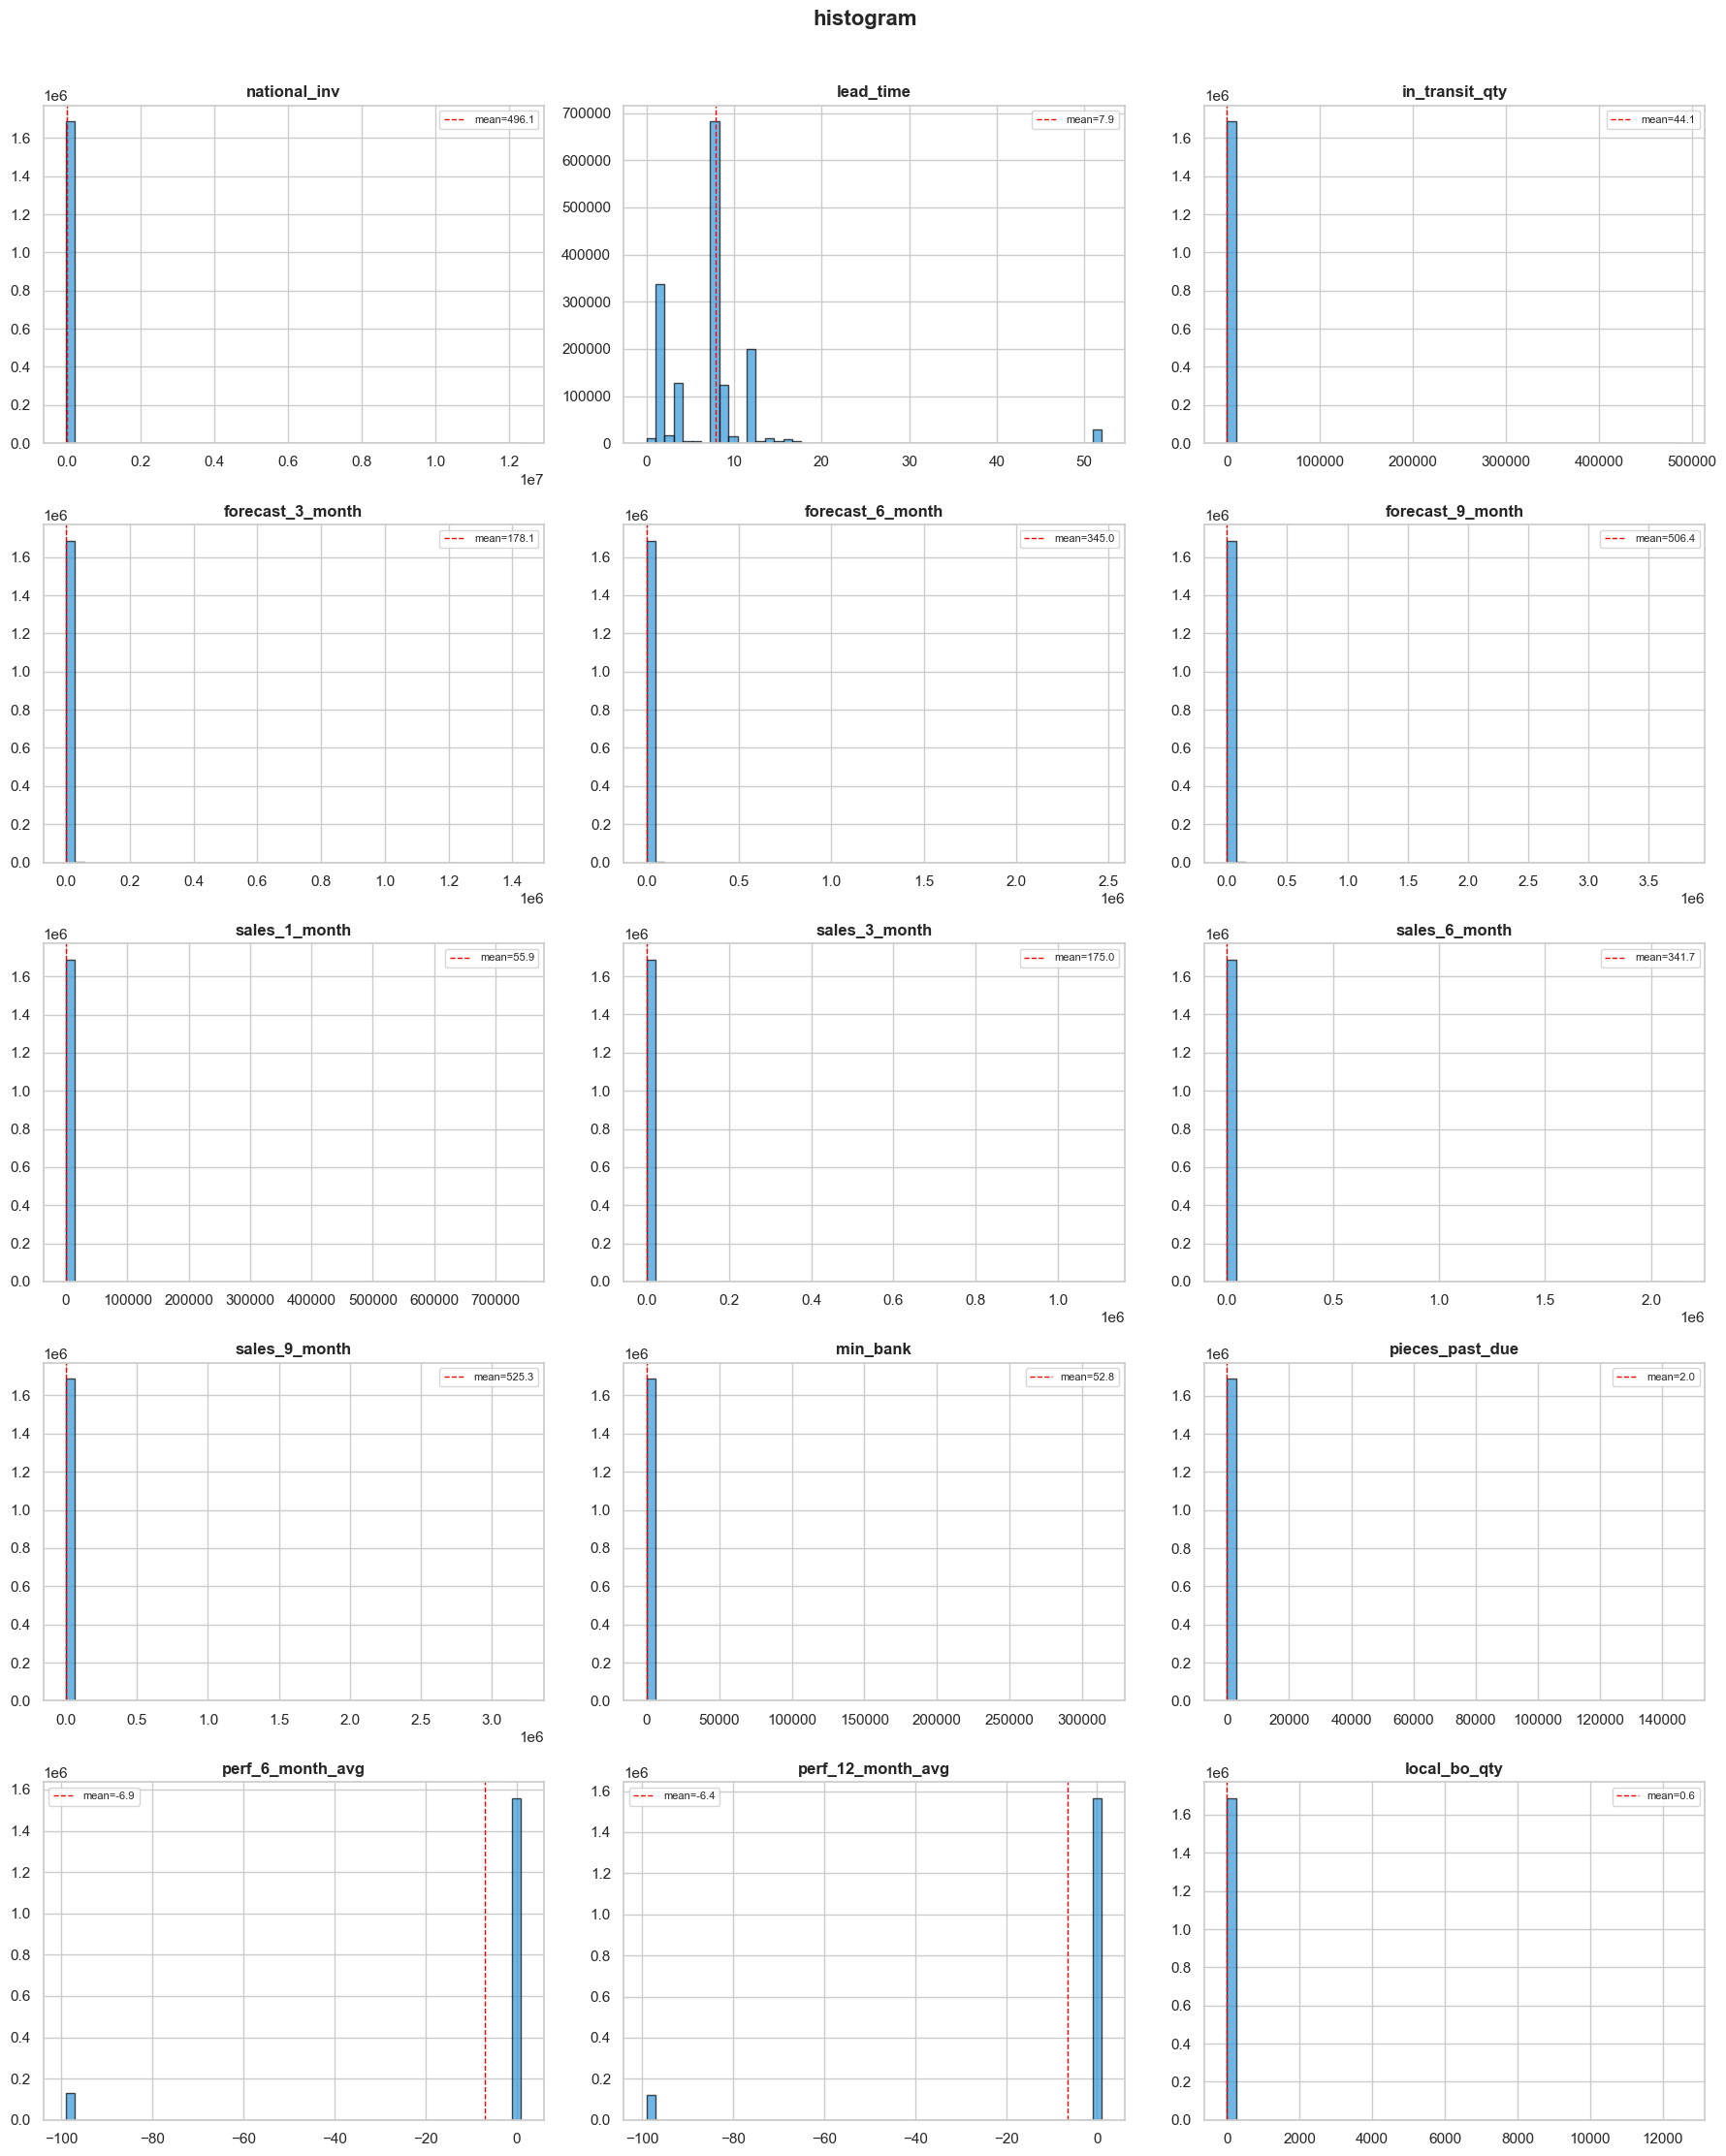

In [71]:
fig, axes = plt.subplots(5, 3, figsize=(18, 22))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    ax = axes[i]
    df_train_eda[col].dropna().hist(bins=50, ax=ax, color='#3498db', edgecolor='black', alpha=0.7)
    ax.set_title(col, fontweight='bold')
    mean_val = df_train_eda[col].mean()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1, label=f'mean={mean_val:.1f}')
    ax.legend(fontsize=8)
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('histogram', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


- 대부분의 수량 피처 (forecast, sales, in_transit_qty, min_bank 등): 대다수 SKU는 값이 0
- perf_6_month_avg / perf_12_month_avg: -99 지점에 점이 찍혀있는 게 보이지? 정상 데이터는 0~1 범위인데 -99 -> 이상치
- lead_time: 유일하게 박스가 눈에 보이는 피처. 이상치도 35,443개로 다른 피처 대비 적은 편.
- pieces_past_due / local_bo_qty: 98%+ 가 0이라 사실상 sparse feature(대부분이 0)
    - 각 상관계수 0.0005 / 0.0095 -> 0 개수가 많은데 YES에 대한 양의 상관관계?

### **편향도 확인**

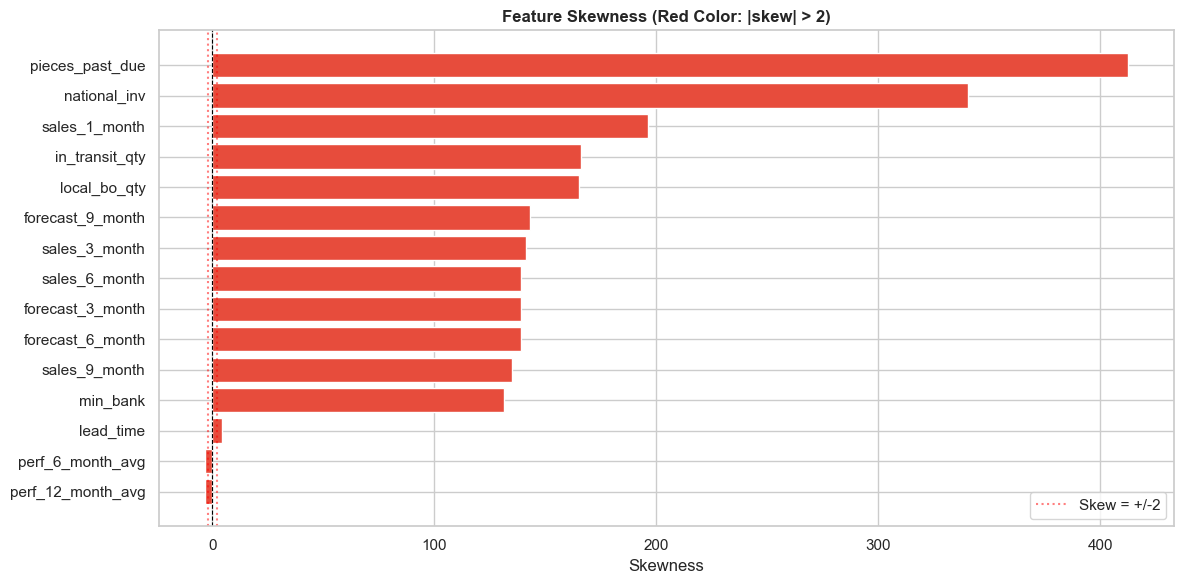

In [72]:
# 왜도 시각화 (편향도) - 데이터 분포가 평균을 중심으로 얼마나 좌우 비대칭적인지(한쪽으로 기울어져 있는지)를 나타내는 통계량
skew_vals = df_train_eda[numeric_cols].skew().sort_values()
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#e74c3c' if abs(v) > 2 else '#3498db' for v in skew_vals.values]
ax.barh(skew_vals.index, skew_vals.values, color=colors)
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax.axvline(x=2, color='red', linestyle=':', alpha=0.5, label='Skew = +/-2')
ax.axvline(x=-2, color='red', linestyle=':', alpha=0.5)
ax.set_xlabel('Skewness') # Skewness = 왜도
ax.set_title('Feature Skewness (Red Color: |skew| > 2)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


|       왜도 값 | 해석                    |
| ---------: | --------------------- |
|       0 근처 | 좌우가 비교적 대칭            |
|         양수 | 오른쪽 꼬리가 김. 일부 값이 매우 큼 |
|         음수 | 왼쪽 꼬리가 김. 일부 값이 매우 작음 |
| skew절대값 > 2 | 비대칭이 꽤 심함             |


- pieces_past_due -> 대부분 SKU는 정상 공급 상태인데, 소수 SKU에서 납기 지연이 집중적,
- national_inv 왜도 약 300 이상. -> SKU별 재고 규모 차이가 매우 큼.
- sales_1_month, sales_3_month, sales_6_month, sales_9_month -> 제품 판매가 특정 SKU에 몰려있음.
- forecast_3_month, forecast_6_month, forecast_9_month: 대부분 제품의 예측 수요는 낮지만, 일부 제품은 매우 높은 수요가 예상됨.
- `local_bo_qty`: 대부분 행에서는 로컬 백오더 수량이 0 또는 작지만, 일부 행에서 백오더 수량이 크게 발생함.

### **범주형 컬럼 보기**

In [73]:
# 범주형 컬럼별 went_on_backorder 교차 분석
binary_flags = ['potential_issue', 'deck_risk', 'oe_constraint', 
                'ppap_risk', 'stop_auto_buy', 'rev_stop']

for col in binary_flags:
    ct = pd.crosstab(df_train_eda[col], df_train_eda['went_on_backorder'])
    ct['backorder_rate(%)'] = ct['Yes'] / (ct['Yes'] + ct['No']) * 100
    ct['total'] = ct['Yes'] + ct['No']
    print(f"\n{'='*50}")
    print(f"  {col}")
    print(f"{'='*50}")
    print(ct[['No', 'Yes', 'total', 'backorder_rate(%)']])


  potential_issue
went_on_backorder       No    Yes    total  backorder_rate(%)
potential_issue                                              
No                 1675711  11242  1686953           0.666409
Yes                    856     51      907           5.622933

  deck_risk
went_on_backorder       No   Yes    total  backorder_rate(%)
deck_risk                                                   
No                 1291000  9377  1300377           0.721099
Yes                 385567  1916   387483           0.494473

  oe_constraint
went_on_backorder       No    Yes    total  backorder_rate(%)
oe_constraint                                                
No                 1676330  11285  1687615           0.668695
Yes                    237      8      245           3.265306

  ppap_risk
went_on_backorder       No   Yes    total  backorder_rate(%)
ppap_risk                                                   
No                 1474492  9534  1484026           0.642442
Yes            

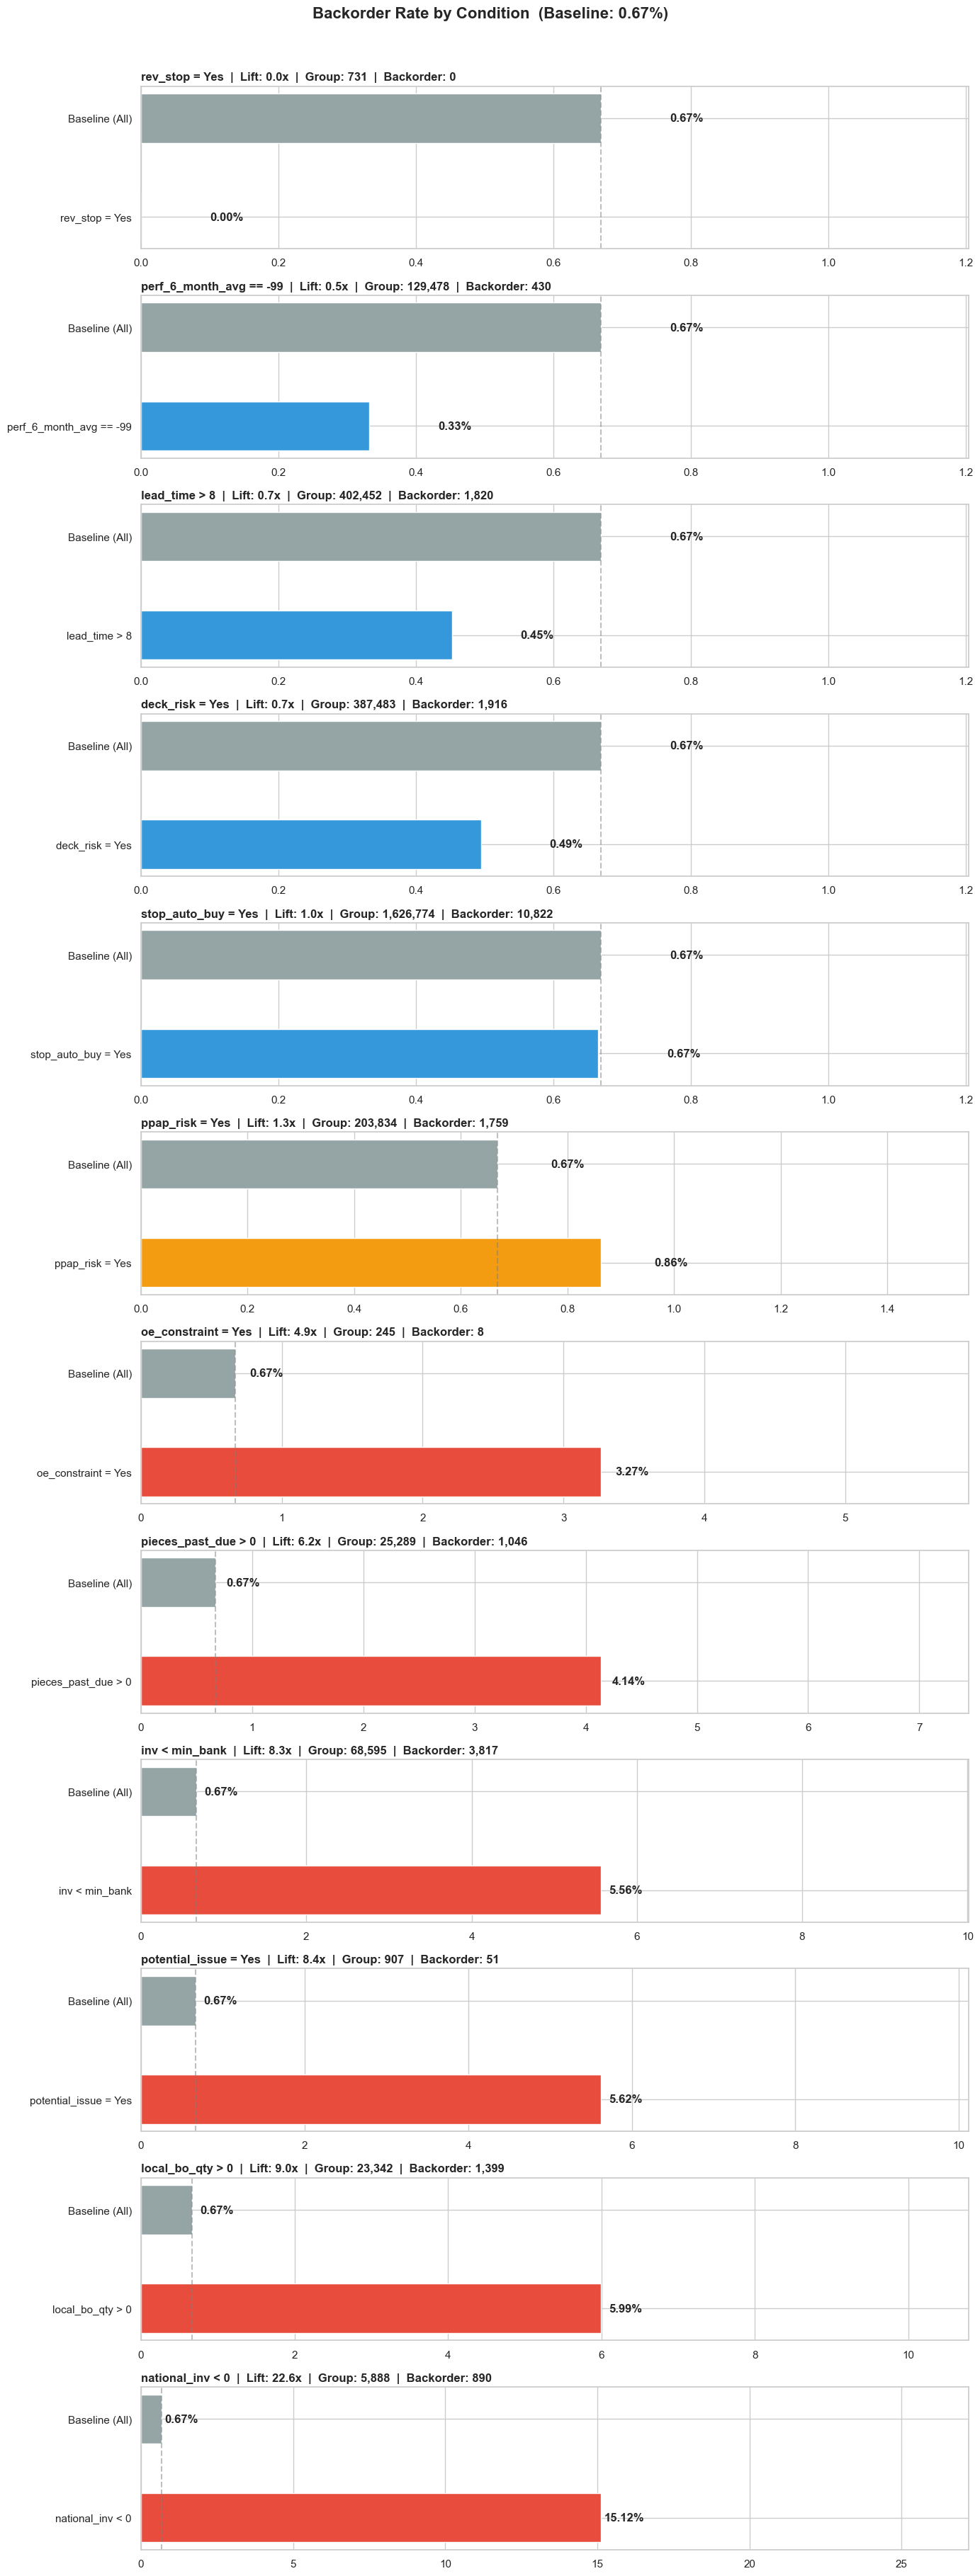

In [74]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 분석할 조건 정의
conditions = {
    'national_inv < 0':        df_train_eda['national_inv'] < 0,
    'local_bo_qty > 0':        df_train_eda['local_bo_qty'] > 0,
    'potential_issue = Yes':   df_train_eda['potential_issue'] == 'Yes',
    'pieces_past_due > 0':     df_train_eda['pieces_past_due'] > 0,
    'oe_constraint = Yes':     df_train_eda['oe_constraint'] == 'Yes',
    'ppap_risk = Yes':         df_train_eda['ppap_risk'] == 'Yes',
    'deck_risk = Yes':         df_train_eda['deck_risk'] == 'Yes',
    'inv < min_bank':          df_train_eda['national_inv'] < df_train_eda['min_bank'],
    'lead_time > 8':           df_train_eda['lead_time'] > 8,
    'perf_6_month_avg == -99': df_train_eda['perf_6_month_avg'] == -99,
    'stop_auto_buy = Yes':     df_train_eda['stop_auto_buy'] == 'Yes',
    'rev_stop = Yes':          df_train_eda['rev_stop'] == 'Yes',
}

target = (df_train_eda['went_on_backorder'] == 'Yes')
baseline_rate = target.mean() * 100

rows = []
for name, mask in conditions.items():
    group = target[mask]
    rate = group.mean() * 100
    lift = rate / baseline_rate if baseline_rate > 0 else 0
    rows.append({
        'condition': name,
        'group_size': mask.sum(),
        'backorder_count': group.sum(),
        'backorder_rate': rate,
        'lift': lift
    })

result = pd.DataFrame(rows).sort_values('lift', ascending=True)

# 시각화
fig, axes = plt.subplots(len(result), 1, figsize=(14, 3 * len(result)))

for i, (_, row) in enumerate(result.iterrows()):
    ax = axes[i]

    labels = [row['condition'], 'Baseline (All)']
    rates = [row['backorder_rate'], baseline_rate]
    colors = ['#e74c3c' if row['lift'] >= 2 else '#f39c12' if row['lift'] >= 1 else '#3498db',
              '#95a5a6']

    bars = ax.barh(labels, rates, color=colors, height=0.5, edgecolor='white')

    # 수치 표시
    for bar, rate in zip(bars, rates):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'{rate:.2f}%', va='center', fontsize=12, fontweight='bold')

    ax.set_title(f'{row["condition"]}  |  Lift: {row["lift"]:.1f}x  |  '
                 f'Group: {row["group_size"]:,}  |  Backorder: {row["backorder_count"]:,.0f}',
                 fontsize=12, fontweight='bold', loc='left')
    ax.set_xlim(0, max(row['backorder_rate'], baseline_rate) * 1.8)
    ax.axvline(x=baseline_rate, color='gray', linestyle='--', alpha=0.5)

plt.suptitle(f'Backorder Rate by Condition  (Baseline: {baseline_rate:.2f}%)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()



---
---

# **정리**
---
## **1. 학습에 해로운 부분**
### **결측치**
- lead_time
    - 100,894개의 결측 - lead_time이 없다는건? 신규 품목이거나 기록 누락이라고 예상됨.
    - 단순 삭제보단 `lead_time_missing` 이진 분류 column 생성
- -99값
    - perf_6_month_avg: 129,478
    - perf_12_month_avg: 122,050
    - 이상치라기보단 `측정 불가` 라고 해석하는게 좋을 듯
    - -99 → NaN 변환 + `perf_missing` column 생성

---

### **이상치**
- 대부분 수치형 column의 편향도가 100~400 수준이다.
    - np.log1p() 필수
- national_inv의 음수 5,888건은 의미 있음 - backorder과 15.12%의 상관관계.
- 대부분 Sparse인 column들
    - oe_constraint - 99.99% No
    - rev_stop - 99.96% No -> flag가 1일 backorder 비율 0%임. `안중요함`
    - potential_issue - 99.95% No / but Yes일 떄의 backorder 비율이 5.62% -> `중요함`

---
---

## **2. 백오더 YES/NO를 구분하기 위한 아이디어**
---
### **확실한 것들**
- `national_inv < 0`인 값(재고 마이너스)
    - 재고가 이미 부족해서 마이너스면 백오더가 걸릴 수 밖에 없다.
- `local_bo_qty > 0` (이미 지역 백오더 존재)
    - 어딘가에서 백오더가 발생한 품목은 추가 백오더 확률이 높다.
- `inv / forcast_3_month <= 1` (재고 대비 수요 예측 비율) - 0.1 이하인 경우 백오더율 7.30%. 수요는 있는데 재고가 거의 없는 상태

---

### 핵심 아이디어: **수요가 있는데 공급이 못 따라가는 상태**를 잡아내야 함.

---
---
## **3. 산업공학 관점에서의 컬럼 조합**
- Supply 측 (재고/공급 능력)
    - `national_inv (현재 전체 재고)` + `in_transit_qty (이동 중 재고)` + `min_bank (안전재고 기준)`
    - 이 세 개가 "지금 가용한 공급 총량"을 결정

- Demand 측 (수요 압력)
    - `forecast_3_month (단기 수요 예측)` + `sales_1_month (최근 실적)` + `local_bo_qty (이미 발생한 미충족 수요)`
    - 이 세 개가 "앞으로의 수요 압력"을 결정

- Risk 측 (공급 리스크)
    - `lead_time (보충 소요 시간)` + `potential_issue (잠재 문제)` + `pieces_past_due (지연 부품)`
    - 리드타임이 길수록 수요 변동에 대응이 느려지고, 이미 지연된 부품이 있으면 연쇄 백오더 가능성 높아짐

- Performance 측
    - `perf_6_month_avg` / `perf_12_month_avg (공급업체 납기 성과)`
    - 성과가 낮을수록(0.5 미만) 백오더율 1.25%로 정상(0.55%) 대비 2배↑



## 전처리 비교

| 항목 | 팀장 문서 | 우리 EDA | 비고 |
|---|---|---|---|
| sku 제거 | O | O | 동일 |
| Yes/No → 1/0 | O | O | 동일 |
| -99 → NaN | O | O | 동일 |
| 결측치 median impute | O | O | 동일 |
| target 결측 행 삭제 | O | O | 동일 |
| national_inv 음수 유지 | O | O | 동일 |
| log1p 스케일링 | X | O | LSTM 입력 스케일 민감 → 필수 |
| rev_stop / stop_auto_buy 제거 검토 | X | O | rev_stop 731건 전부 backorder=No, stop_auto_buy lift 0.9x |
| perf_missing flag | X | O | 결측 자체가 정보 (결측 그룹 backorder율 0.33% vs 정상 0.70%) |
| lead_time_missing flag | X | O | 같은 논리 |

## 파생 변수 비교

| 파생변수 | 출처 | 계산식 | 대응 변수 | 차이점 |
|---|---|---|---|---|
| available_inventory | 팀장 | national_inv − min_bank | safety_stock_gap (우리) | 동일 개념, 이름만 다름 |
| real_available_inventory | 팀장 | national_inv − min_bank − local_bo_qty | 없음 | 팀장 고유. local_bo_qty까지 차감하여 실질 가용재고 계산 |
| future_available_inventory_3m | 팀장 | national_inv + in_transit_qty − min_bank − forecast_3_month | supply_demand_gap (우리) | 팀장이 min_bank도 차감 → SCM 관점 더 정확 |
| shortage_ratio_3m | 팀장 | (forecast − inv − transit) / (forecast + 1) | inv_coverage_ratio (우리) | 관점 다름. 팀장=미래 수요 기반 부족 비율, 우리=과거 판매 기반 커버리지 |
| no_sales_but_demand_signal | 팀장 | sales_6m==0 & (forecast>0 \| bo>0) → 0/1 | 없음 | 팀장 고유. 판매=0이지만 수요 신호 존재하는 케이스 포착 |

